# Graph Construction

Calls `src/graphs.py` functions. Includes SAGEConv directionality verification.
No logic lives here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import config
from src.graphs import (
    build_correlation_graph, save_correlation_samples,
    build_sector_graph, build_granger_graph,
    build_all_sector_graphs, make_pyg_data
)

## Sector Graph

In [2]:
import json
from collections import Counter

with open("../data/raw/tickers.json") as f:
    tickers = json.load(f)
with open("../data/raw/sector_history.json") as f:
    sector_history = json.load(f)

# Build all sector graphs and save parquet
sector_graphs = build_all_sector_graphs(tickers, sector_history, range(2015, 2026))

# Node counts per sector per year
for year in [2016, 2017]:
    counts = Counter(
        sector_history.get(t, {}).get(str(year))
        for t in tickers
        if sector_history.get(t, {}).get(str(year))
    )
    print(f"\n{year} — {len(counts)} sectors, {sum(counts.values())} nodes")
    for sector, n in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {sector}: {n}")

Saved 3872 total edges across 11 years to C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\graphs\sector_edges_by_year.parquet

2016 — 10 sectors, 50 nodes
  Financial Services: 12
  Technology: 10
  Healthcare: 9
  Consumer Cyclical: 7
  Utilities: 3
  Industrials: 3
  Consumer Defensive: 2
  Financials: 2
  Energy: 1
  Basic Materials: 1

2017 — 10 sectors, 50 nodes
  Financial Services: 12
  Technology: 10
  Healthcare: 9
  Consumer Cyclical: 7
  Utilities: 3
  Industrials: 3
  Consumer Defensive: 2
  Real Estate: 2
  Energy: 1
  Basic Materials: 1


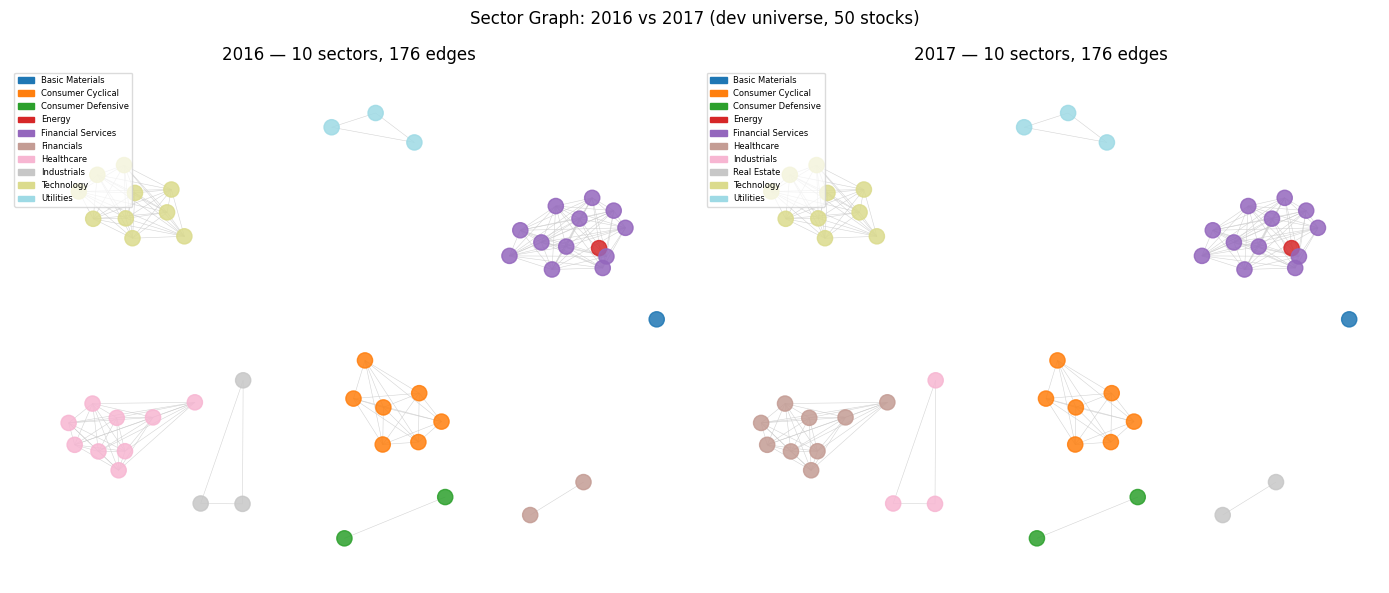

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_sector_graph(tickers, sector_graphs, sector_history, year, ax):
    edge_index = sector_graphs[year]
    G = nx.Graph()
    G.add_nodes_from(range(len(tickers)))
    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()
    # Add only one direction to avoid duplicate edges in undirected nx graph
    edges = {(min(s, d), max(s, d)) for s, d in zip(src, dst)}
    G.add_edges_from(edges)

    sectors = [sector_history.get(t, {}).get(str(year), "Unknown") for t in tickers]
    unique_sectors = sorted(set(sectors))
    color_map = {s: plt.cm.tab20(i / max(len(unique_sectors) - 1, 1))
                 for i, s in enumerate(unique_sectors)}
    node_colors = [color_map[s] for s in sectors]

    pos = nx.spring_layout(G, seed=config.RANDOM_SEED, k=0.6)
    nx.draw_networkx(G, pos=pos, ax=ax, node_color=node_colors,
                     node_size=120, with_labels=False, edge_color="#cccccc",
                     width=0.4, alpha=0.85)
    legend_handles = [mpatches.Patch(color=color_map[s], label=s) for s in unique_sectors]
    ax.legend(handles=legend_handles, fontsize=6, loc="upper left", framealpha=0.7)
    ax.set_title(f"{year} — {len(unique_sectors)} sectors, {G.number_of_edges()} edges")
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_sector_graph(tickers, sector_graphs, sector_history, 2016, axes[0])
plot_sector_graph(tickers, sector_graphs, sector_history, 2017, axes[1])
plt.suptitle("Sector Graph: 2016 vs 2017 (dev universe, 50 stocks)", fontsize=12)
plt.tight_layout()
plt.show()

## Correlation Graph

In [4]:
import pandas as pd

log_returns = pd.read_parquet("../data/raw/log_returns.parquet")
print(f"log_returns shape: {log_returns.shape}")
print(f"Date range: {log_returns.index[0].date()} to {log_returns.index[-1].date()}")

log_returns shape: (2764, 50)
Date range: 2015-01-05 to 2025-12-30


In [5]:
print(f"Building correlation graphs (threshold θ={config.CORR_THRESHOLD}, "
      f"lookback={config.CORR_LOOKBACK_DAYS} days):\n")
corr_samples = save_correlation_samples(log_returns, tickers)

Building correlation graphs (threshold θ=0.5, lookback=252 days):

  calm     (2017-06-30):     92 directed edges  (   46 unique pairs)
  covid    (2020-03-13):   1724 directed edges  (  862 unique pairs)
  recent   (2023-06-30):    788 directed edges  (  394 unique pairs)


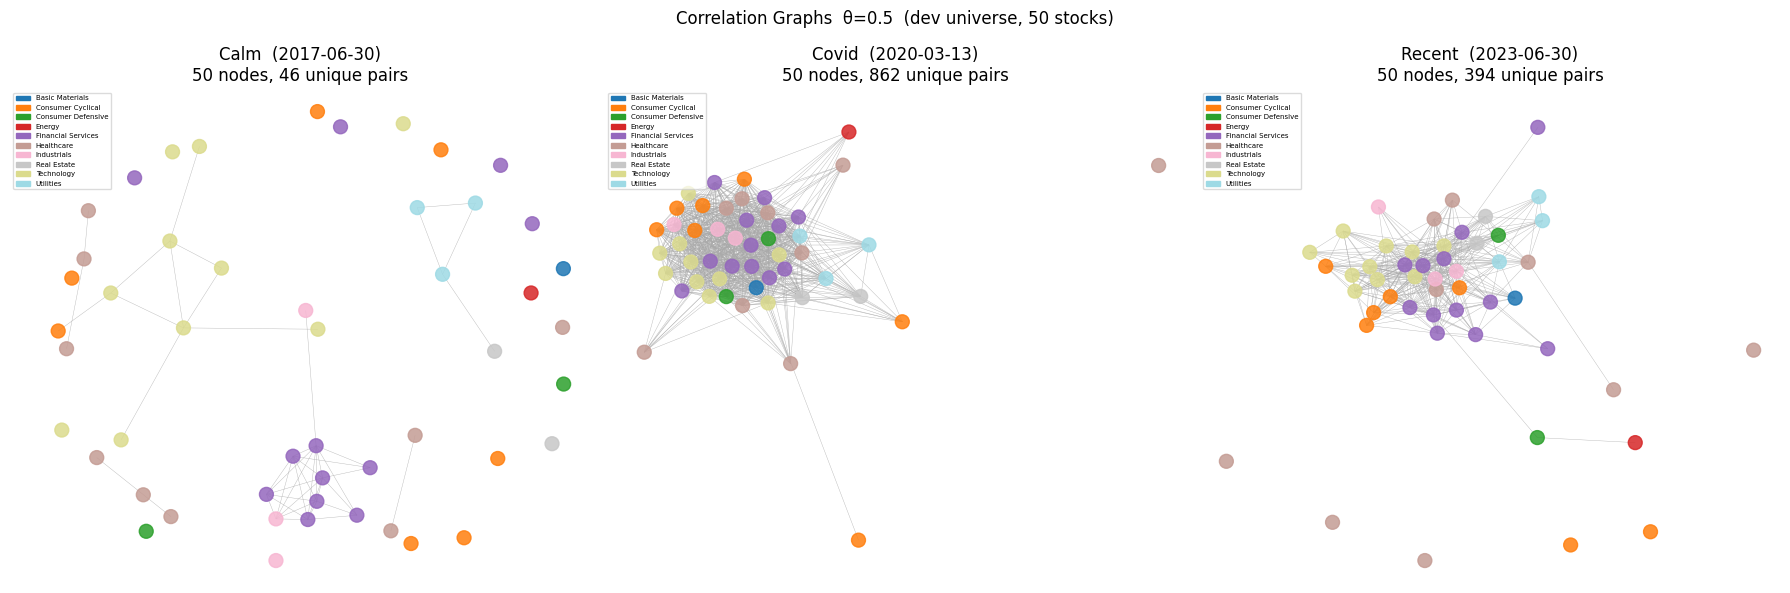

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Year used for sector coloring in each sample graph
_SAMPLE_YEARS = {"calm": 2017, "covid": 2020, "recent": 2023}

def plot_correlation_graph(edge_index, tickers, sector_history, year, ax, title):
    G = nx.Graph()
    G.add_nodes_from(range(len(tickers)))
    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()
    edges = {(min(s, d), max(s, d)) for s, d in zip(src, dst)}
    G.add_edges_from(edges)

    sectors = [sector_history.get(t, {}).get(str(year), "Unknown") for t in tickers]
    unique_sectors = sorted(set(sectors))
    color_map = {s: plt.cm.tab20(i / max(len(unique_sectors) - 1, 1))
                 for i, s in enumerate(unique_sectors)}
    node_colors = [color_map[s] for s in sectors]

    pos = nx.spring_layout(G, seed=config.RANDOM_SEED, k=0.6)
    nx.draw_networkx(G, pos=pos, ax=ax, node_color=node_colors,
                     node_size=100, with_labels=False, edge_color="#aaaaaa",
                     width=0.3, alpha=0.85)
    legend_handles = [mpatches.Patch(color=color_map[s], label=s) for s in unique_sectors]
    ax.legend(handles=legend_handles, fontsize=5, loc="upper left", framealpha=0.7)
    ax.set_title(f"{title}\n{G.number_of_nodes()} nodes, {G.number_of_edges()} unique pairs")
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for (label, date_str), ax in zip(config.CORR_SAMPLE_DATES.items(), axes):
    plot_correlation_graph(
        corr_samples[label], tickers, sector_history,
        _SAMPLE_YEARS[label], ax,
        title=f"{label.capitalize()}  ({date_str})"
    )
plt.suptitle(f"Correlation Graphs  θ={config.CORR_THRESHOLD}  (dev universe, {len(tickers)} stocks)",
             fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
calm_edges  = corr_samples["calm"].shape[1]
covid_edges = corr_samples["covid"].shape[1]
assert covid_edges > calm_edges, (
    f"Expected COVID edge count ({covid_edges}) > calm ({calm_edges})"
)
print(f"Edge count rises from calm to COVID: {calm_edges} -> {covid_edges} (confirmed)")

Edge count rises from calm to COVID: 92 -> 1724 (confirmed)
